# Squarify

In [1]:
import pyPolygon as pp
import numpy as np
from matplotlib import pyplot as plt
import records # These are the record densities and edge lengths for N

We begin by making a packing of 32-gons with kappa = 4 and minimizing it with by overlap area and then by overlap depth:

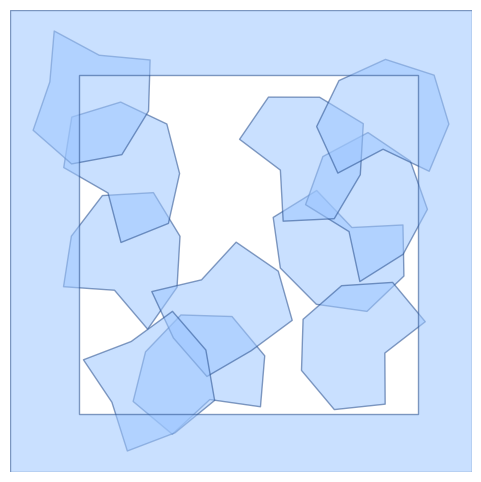

In [2]:
N = 11 # number of squares (eventually)
phiStart = 1.0
phiEnd = (N / records.bestKnownSide(N)**2) * 1.02 # Make it 2% denser than the optimum
wallStiffness = 100
excess = 1e-6

packing = pp.Model(N = N, n = 8, seed = 42)
packing.generateEquilateralPolygons(phi = phiStart, kappa = 4)
packing.syncTargetAreas()
packing.syncTargetPerimeters()
# We want finite boundary conditions:
packing.addShape(np.array([[0, 0], [0, 1], [1, 1], [1, 0]]))
packing.pinVertices(np.arange(packing.getNumVertices())[-4:])
packing.setBoundaryConditions("fixed")
# We want to constrain the edges and areas
packing.setConstraints(area = True, edge = True)
packing.draw()
plt.show()

## We start by minimizing with respect to the overlap area

FIRE (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

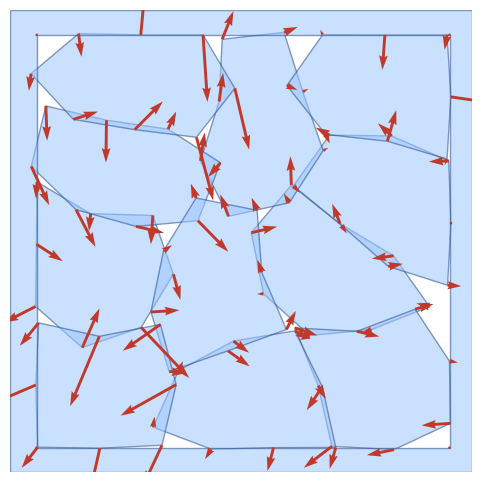

In [3]:
packing.minimizeFIRE(maxSteps = 1000, maxUnbalancedForce = 7e-3, progressBar = True)
packing.draw(forces = packing.getForces())
plt.show()

However, for squares we don't want overlap area, but depth will work.

Additionally, we need the walls to be stiff so we can set that:

In [4]:
packing.setModelType("depth")
packing.setContainerStiffness(wallStiffness)

We can then minimize with respect to the depth

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

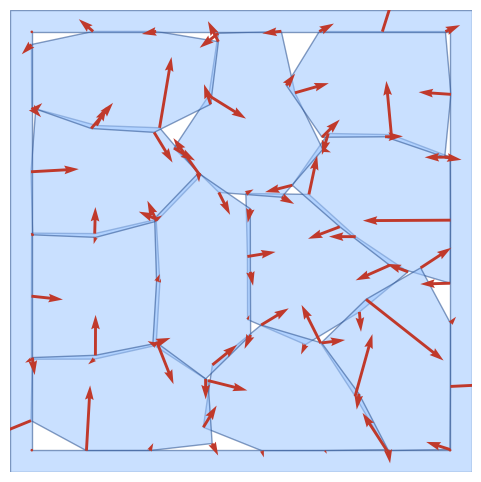

In [5]:
#packing.minimizeFIRE(maxSteps = 1000, maxUnbalancedForce = 1e-7, progressBar = True)
packing.minimizeLBFGS(maxSteps = 1000, maxUnbalancedForce = 1e-10, progressBar = True)
packing.draw(forces = packing.getForces())
plt.show()

## Next we need to get the excess energy down to the value set as "excess"

  hold     phi 1.000000  excess 1.0376e-04  (target 1.0000e-06)  pairOverlap 2.624e-02
  hold     phi 0.952381  excess 3.5295e-08  (target 1.0000e-06)  pairOverlap 1.007e-03
  hold     phi 0.975900  excess 1.2514e-05  (target 1.0000e-06)  pairOverlap 1.180e-02
  hold     phi 0.964069  excess 1.6693e-06  (target 1.0000e-06)  pairOverlap 5.461e-03
  hold     phi 0.961082  excess 7.5658e-07  (target 1.0000e-06)  pairOverlap 3.971e-03
  hold     phi 0.962134  excess 1.0204e-06  (target 1.0000e-06)  pairOverlap 4.516e-03


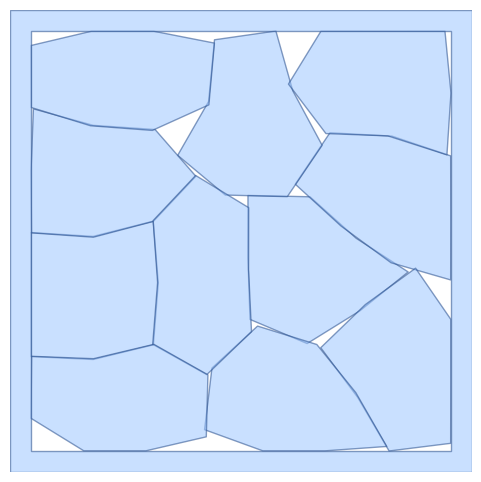

In [6]:
packing.holdExcessEnergy(excess, minimizer = "lbfgs", verbose = True)
packing.draw()
plt.show()

Next we get the distribution of every other diagonal and generate a schedule that will pull these to 0

### A single deficit budget, not the mean

`alternatingDiagonal = [1]` holds the mean flatness across the whole packing, which has no purchase on the tail -- it advances by flattening vertices that are already nearly flat while the worst one lags or regresses. `deviation = True` switches the held quantity from `t` to the flatness DEFICIT `1 - t`, nonnegative by the triangle inequality, so the row is a one-sided budget rather than a moment. `[2]` weights the gradient toward the worst vertices (`d(sum delta^2)/dr` carries a factor of `delta`), and it stays a single row -- no width to narrow, so it cannot go numerically parallel the way a mean/variance pair does.

Driven to the same nominal target on a rounded 4-square test system: mean-only left the worst vertex at `0.9604` (spread `0.0196`); this form reached `0.9717` (spread `0.0141`) for `p = 2`, and `0.9762` (spread `0.0119`) for `p = 4`. See `tests/diagonalDeviationCheck.py`.

### We slightly push the target edges toward 2l

In [7]:
numSteps = 18
def getNewTargets(step, numSteps, n):
    positions = packing.getVertices()[:-4].reshape(N, n, 2)
    v1 = positions[:, ::2]
    v2 = np.roll(v1, 1, axis = 1)
    alternatingDiagonals = np.sqrt(np.sum((v2 - v1)**2, axis = 2))
    targetDiagonal = 2 * np.mean(np.sqrt(np.sum((positions - np.roll(positions, 1, axis = 1))**2, axis = 2)))
    return (targetDiagonal - alternatingDiagonals) * step / numSteps + alternatingDiagonals

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962134  excess 1.0913e-06  (target 3.2000e-07)  pairOverlap 4.570e-03


/home/rdennis/Documents/Code/pyPolygon/model.py:3695: UserWarning: 
*** the requested maxUnbalancedForce 3.00e-11 is within a decade of the noise floor 3.0e-12 ***
    Reachable, but the last decade is mostly roundoff and will cost far more steps than the ones before it.
  threshold = self._convergenceThreshold(maxUnbalancedForce, fThreshold, 1e-9)
/home/rdennis/Documents/Code/pyPolygon/model.py:3735: UserWarning: 
*** the requested maxUnbalancedForce 3.00e-11 is within a decade of the noise floor 3.0e-12 ***
    Reachable, but the last decade is mostly roundoff and will cost far more steps than the ones before it.
  threshold = self._convergenceThreshold(maxUnbalancedForce, fThreshold, 1e-9)


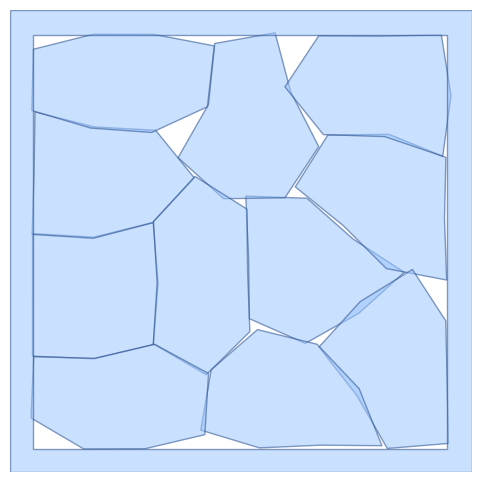

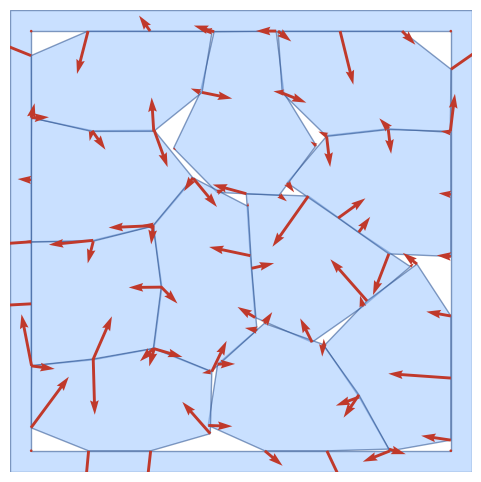

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962134  excess 2.8446e-06  (target 3.2000e-07)  pairOverlap 7.128e-03


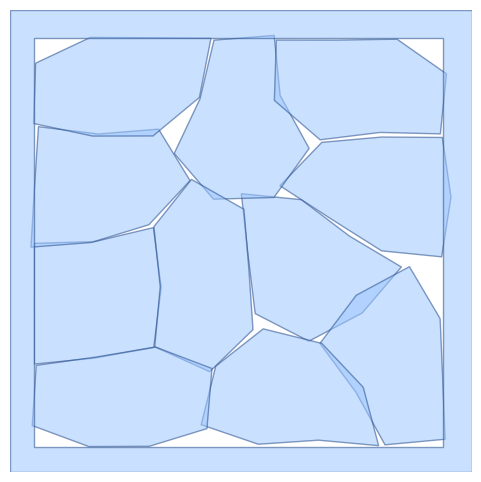

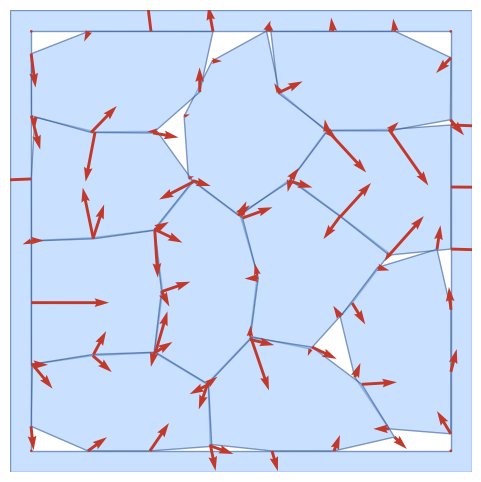

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962134  excess 3.8104e-06  (target 3.2000e-07)  pairOverlap 8.618e-03


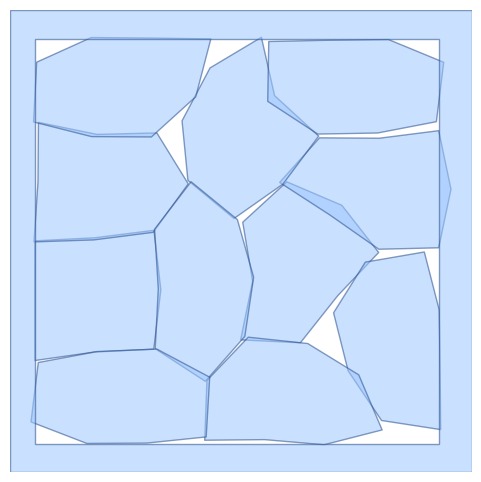

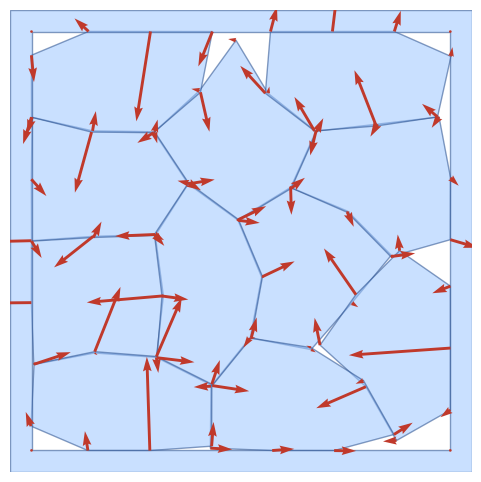

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962134  excess 1.9880e-06  (target 3.2000e-07)  pairOverlap 6.332e-03


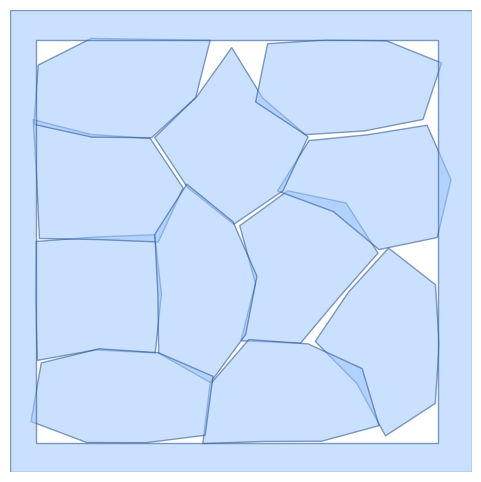

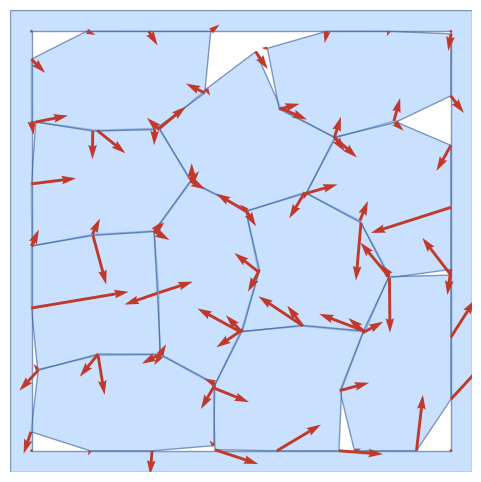

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.962134  excess 4.1263e-05  (target 3.2000e-07)  pairOverlap 1.765e-02
  hold     phi 0.916318  excess 6.6024e-07  (target 3.2000e-07)  pairOverlap 1.032e-03


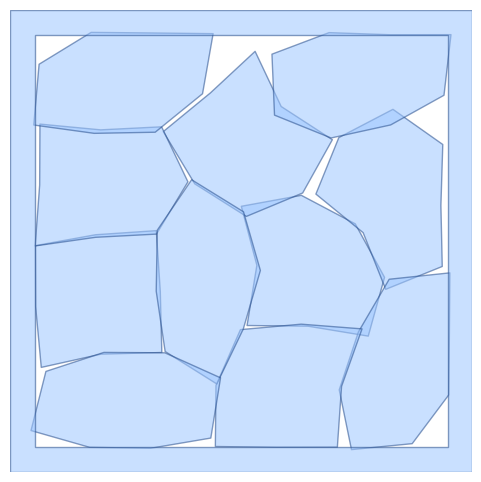

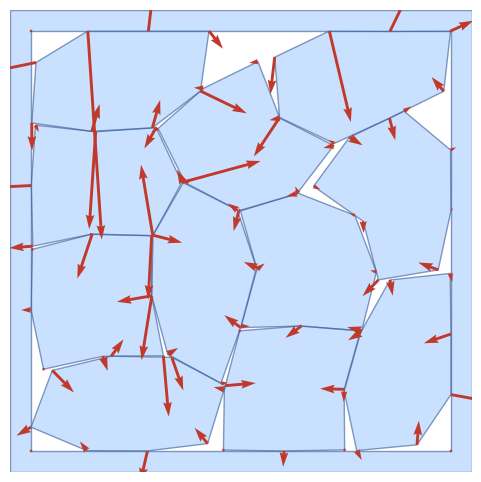

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.916318  excess 2.5148e-06  (target 3.2000e-07)  pairOverlap 5.090e-03


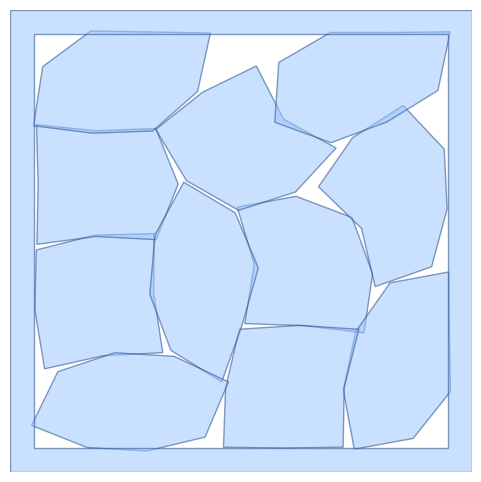

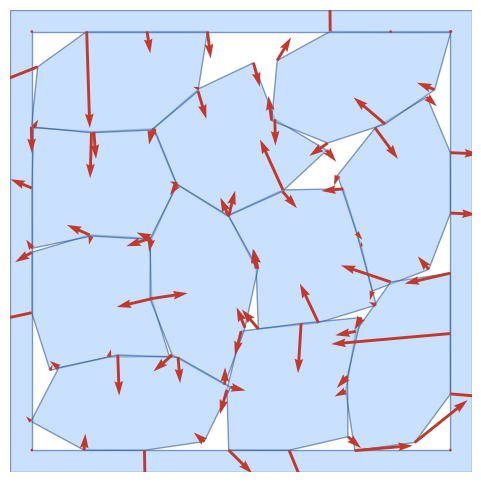

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.916318  excess 3.1191e-06  (target 3.2000e-07)  pairOverlap 4.315e-03


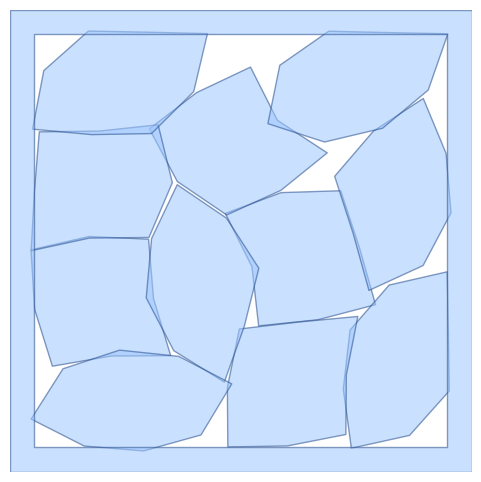

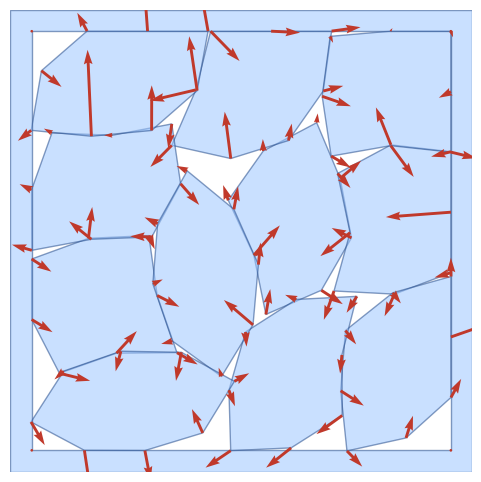

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.916318  excess 1.1113e-04  (target 3.2000e-07)  pairOverlap 1.518e-02
  hold     phi 0.872684  excess 8.2367e-06  (target 3.2000e-07)  pairOverlap 4.041e-03


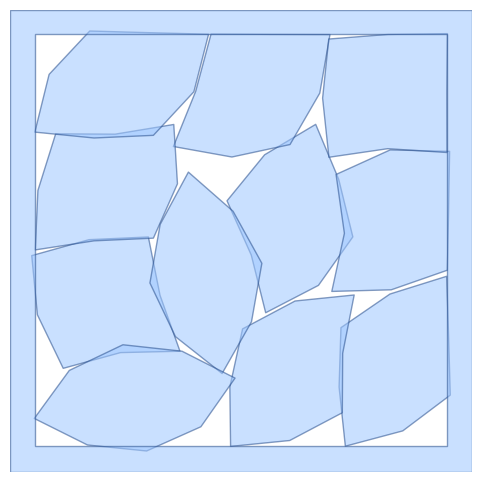

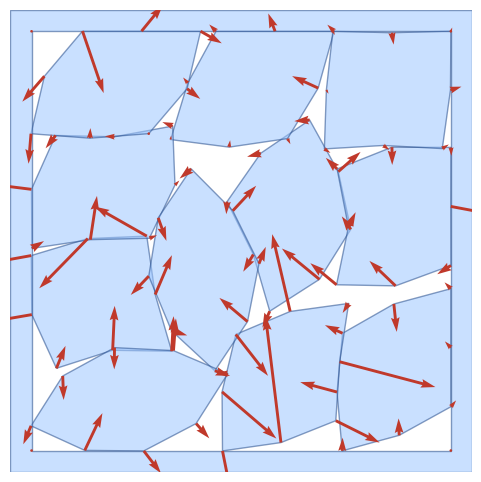

/tmp/ipykernel_21874/3853941108.py:4: UserWarning: 
*** 1 diagonal targets exceed a + b and cannot be reached ***
    the worst asks for 1.0000 times the sum of its own two edges, and the triangle inequality caps a diagonal at exactly that sum.
    The edge and diagonal springs will settle at a compromise and the relaxation will report itself converged, having missed. Note that a target AT the cap is degenerate rather than merely tight: the vertex is then collinear, so the pull that straightens it has vanished. Aim just short.
  packing.updateAlternatingDiagonals(targets = getNewTargets(step, numSteps, 8))


L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.872684  excess 1.1642e-04  (target 3.2000e-07)  pairOverlap 1.188e-02
  hold     phi 0.831128  excess 1.0289e-05  (target 3.2000e-07)  pairOverlap 3.246e-03
  hold     phi 0.791550  excess 3.9061e-07  (target 3.2000e-07)  pairOverlap 2.974e-04


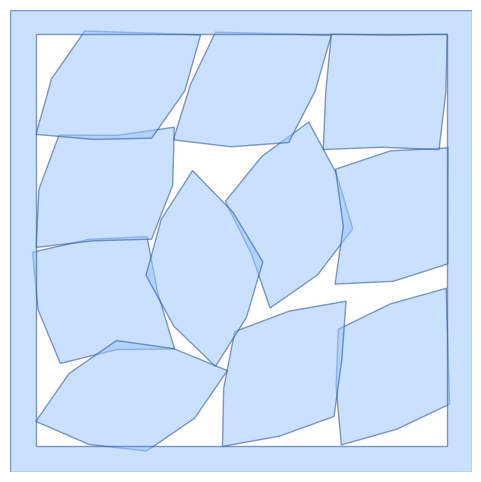

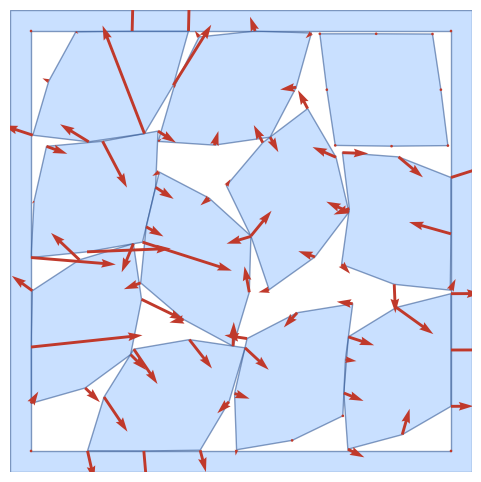

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.791550  excess 1.5235e-08  (target 3.2000e-07)  pairOverlap 2.241e-04


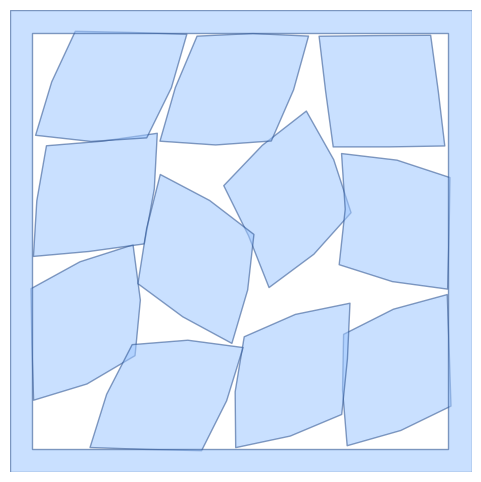

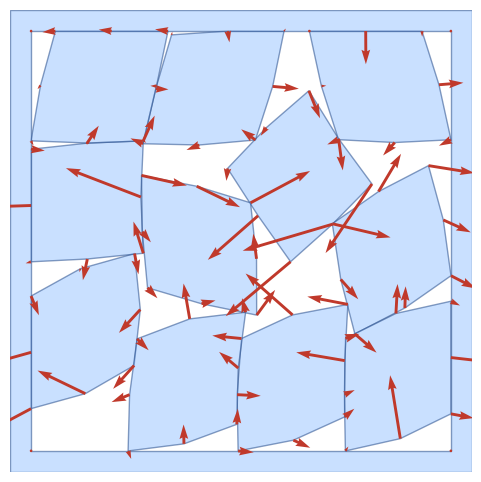

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.791550  excess 1.3751e-05  (target 3.2000e-07)  pairOverlap 3.555e-03
  hold     phi 0.753857  excess 6.6096e-07  (target 3.2000e-07)  pairOverlap 3.584e-04


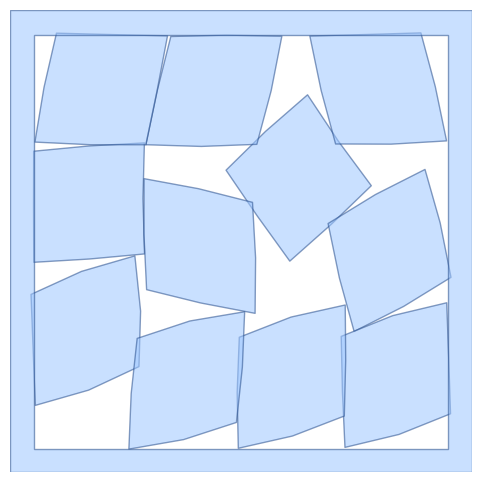

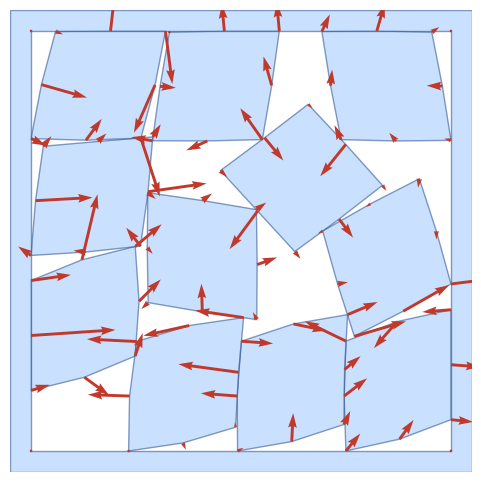

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.753857  excess 4.2560e-06  (target 3.2000e-07)  pairOverlap 1.716e-03


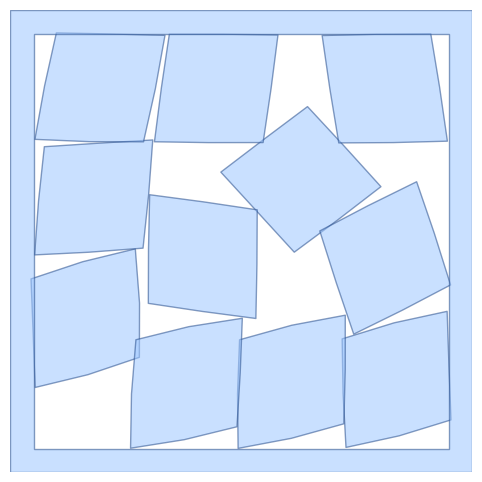

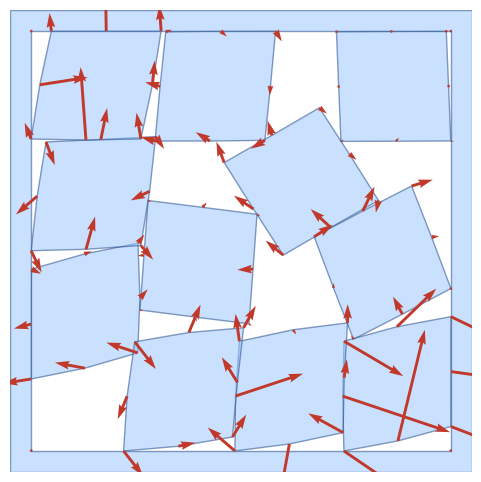

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.753857  excess 1.6473e-05  (target 3.2000e-07)  pairOverlap 2.856e-03
  hold     phi 0.717959  excess 2.1535e-06  (target 3.2000e-07)  pairOverlap 3.556e-04


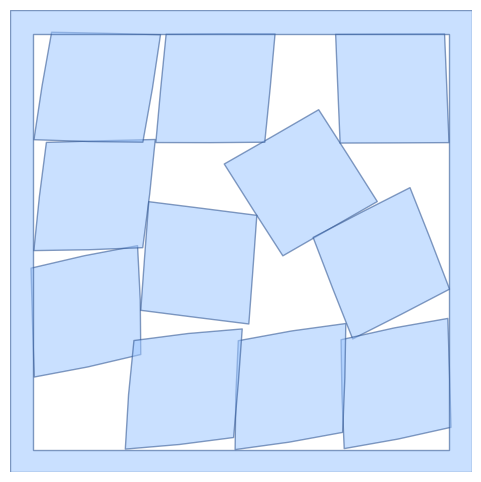

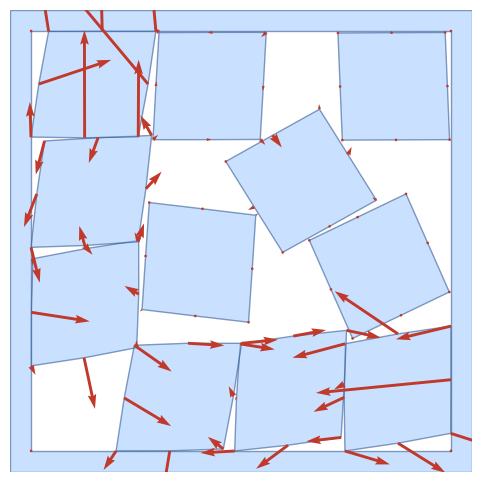

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.717959  excess 8.8638e-07  (target 3.2000e-07)  pairOverlap 6.974e-04


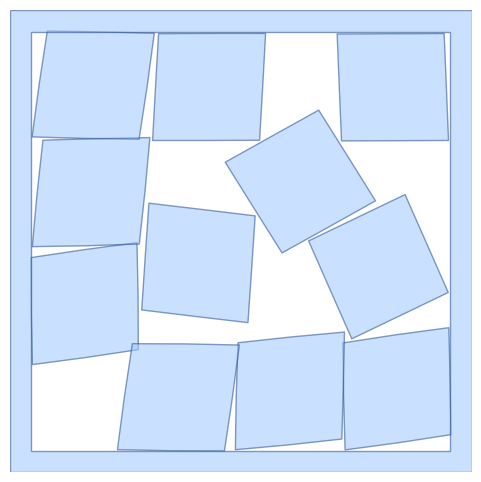

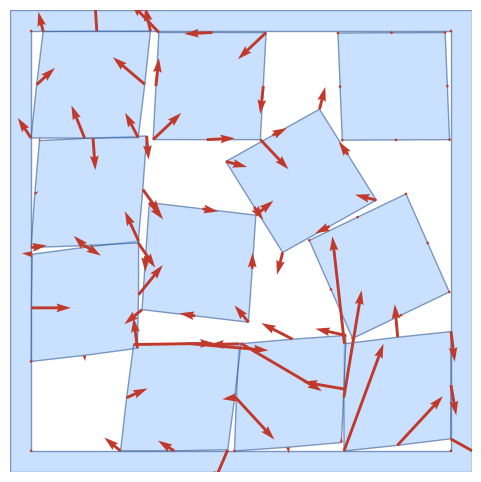

L-BFGS (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]

  hold     phi 0.717959  excess 1.8511e-06  (target 3.2000e-07)  pairOverlap 1.067e-03


KeyboardInterrupt: 

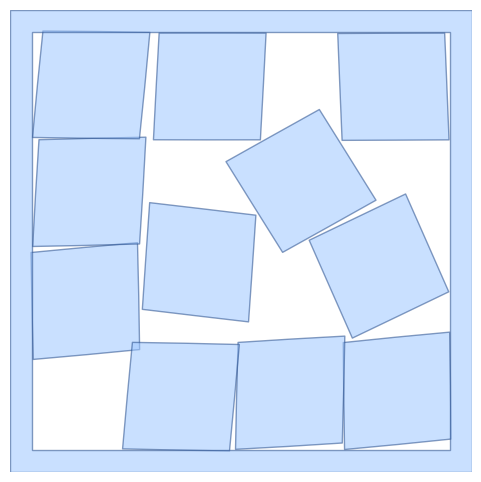

In [8]:
# We constrain these diagonals:
packing.setConstraints(edge = True, area = True, alternatingDiagonal = [2], deviation = True)
for step in range(1, numSteps + 1):
    packing.updateAlternatingDiagonals(targets = getNewTargets(step, numSteps, 8))
    packing.setModelType("depth")
    packing.setConstraints(edge = True, area = True, alternatingDiagonal = [2], deviation = True)
    packing.draw(forces = packing.getForces())
    packing.minimizeLBFGS(maxSteps = 1000, maxUnbalancedForce = 1e-10, progressBar = True)
    packing.holdExcessEnergy(3.2e-7, tolerance = 3.4,
                             maxUnbalancedForce = 1e-6, maxSteps = 2000,
                             minimizer = "lbfgs", verbose = True)
    packing.minimizeFireLBFGS(maxUnbalancedForce = 3e-11)
    packing.draw(forces = packing.getForces())
    plt.show()

In [ ]:
np.std(getNewTargets(0, numSteps, 8))

In [ ]:
packing.draw()
plt.show()
packing.setModelType("sharp")
packing.minimizeFIRE(maxSteps = 2000, maxUnbalancedForce = 1e-3)
packing.draw()
plt.show()